<a href="https://colab.research.google.com/github/Heman659-crypto/ecommerce-data-processing-/blob/main/Ecommerce_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

# 🛒 E-Commerce Data Processing & Analysis
### A Pandas + NumPy Data Engineering Pipeline

**Combining Orders, Customers & Products into a Clean, Analysis-Ready Dataset**

</div>

| | |
|---|---|
| **Author** | Heman|
| **Course / Batch** |IDRA Data Science & Analytics|

| **Assignment** | Day 9 — Merge, Concat, Apply & DateTime Operations |
| **Environment** | Google Colab / Jupyter Notebook |
| **Libraries** | NumPy · Pandas · Matplotlib |

---

## 🎯 Objective

Raw e-commerce data is rarely analysis-ready — it's scattered across separate
tables for orders, customers, and products. This notebook builds a single,
clean, **processed dataset** by combining three raw CSV files:

| Source File | Description | Rows |
|---|---|---|
| `Day9_Orders.csv` | Transaction-level order records | 120 |
| `Day9_Customers.csv` | Customer master data | 30 |
| `Day9_Products.csv` | Product catalog with pricing | 20 |

## 🧰 Core Techniques Demonstrated

| # | Technique | Library |
|---|---|---|
| 1 | Loading & inspecting structured data | Pandas |
| 2 | Combining tables with **`merge()`** | Pandas |
| 3 | Stacking DataFrames with **`concat()`** | Pandas |
| 4 | Row-wise & vectorized feature engineering — **`apply()`**, `np.where`, `np.select` | Pandas + NumPy |
| 5 | Statistical summaries & outlier detection (IQR method) | NumPy |
| 6 | **DateTime** parsing & feature extraction | Pandas |
| 7 | Multi-panel data visualization | Matplotlib |
| 8 | Exporting a clean, final dataset | Pandas |

---

## 📑 Table of Contents

1. [Environment Setup](#section1)
2. [Load & Preview Datasets](#section2)
3. [Data Quality Audit](#section3)
4. [Combining Data with `merge()`](#section4)
5. [Demonstrating `concat()`](#section5)
6. [DateTime Feature Engineering](#section6)
7. [Feature Engineering with `apply()` & NumPy](#section7)
8. [Outlier Detection using NumPy (IQR Method)](#section8)
9. [Building the Final Dataset](#section9)
10. [Visual Insights Dashboard](#section10)
11. [Exporting the Processed Dataset](#section11)
12. [Conclusion](#section12)

---

<a id="section1"></a>
## 1️⃣ Environment Setup

This notebook is written to run seamlessly in **Google Colab** or a local
**Jupyter** environment. We detect the runtime automatically, then import
and configure our three core libraries.

In [ ]:
# Detect whether this notebook is running on Google Colab or locally
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

Running in Google Colab: True


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Display & plotting configuration (professional defaults) ----
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

COLOR_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

print("✅ NumPy, Pandas & Matplotlib imported and configured")
print(f"   NumPy version      : {np.__version__}")
print(f"   Pandas version     : {pd.__version__}")
print(f"   Matplotlib version : {matplotlib.__version__}" if 'matplotlib' in dir() else "")

✅ NumPy, Pandas & Matplotlib imported and configured
   NumPy version      : 2.1.3
   Pandas version     : 2.2.3



<a id="section2"></a>
## 2️⃣ Load & Preview Datasets

**If running on Google Colab**, upload the three CSV files first:

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Day9_Customers.csv to Day9_Customers.csv
Saving Day9_Orders.csv to Day9_Orders.csv
Saving Day9_Products.csv to Day9_Products.csv


In [ ]:
# Resolve the data directory depending on environment
DATA_DIR = "data" if not IN_COLAB else "."

orders_df    = pd.read_csv(f"{DATA_DIR}/Day9_Orders.csv")
customers_df = pd.read_csv(f"{DATA_DIR}/Day9_Customers.csv")
products_df  = pd.read_csv(f"{DATA_DIR}/Day9_Products.csv")

print("Dataset shapes (rows, columns):")
print(f"  Orders    : {orders_df.shape}")
print(f"  Customers : {customers_df.shape}")
print(f"  Products  : {products_df.shape}")

Dataset shapes (rows, columns):
  Orders    : (120, 7)
  Customers : (30, 5)
  Products  : (20, 5)


In [ ]:
orders_df.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Payment_Method,Order_Status
0,O0001,2026-02-19,C027,P019,2,Credit Card,Delivered
1,O0002,2026-01-25,C006,P003,2,Debit Card,Delivered
2,O0003,2026-02-26,C015,P004,1,Cash on Delivery,Delivered
3,O0004,2026-03-04,C024,P015,3,Net Banking,Delivered
4,O0005,2026-03-29,C025,P009,5,Credit Card,Delivered


In [ ]:
customers_df.head()

,Customer_ID,Customer_Name,City,Region,Membership_Type
0,C001,Aarav Sharma,Srinagar,North,Premium
1,C002,Zoya Khan,Delhi,North,Regular
2,C003,Rohan Mehta,Mumbai,West,Premium
3,C004,Ananya Singh,Jammu,North,Regular
4,C005,Kabir Ali,Lucknow,North,New


In [ ]:
products_df.head()

,Product_ID,Product_Name,Category,Unit_Price,Brand
0,P001,Wireless Headphones,Electronics,1499,SoundMax
1,P002,Mechanical Keyboard,Electronics,2499,KeyPro
2,P003,Wireless Mouse,Electronics,899,TechGear
3,P004,Smart Watch,Electronics,3299,FitTech
4,P005,Power Bank,Electronics,1199,VoltPlus


<a id="section3"></a>
## 3️⃣ Data Quality Audit

Before combining tables, we validate **data types, missing values,
duplicates**, and use **NumPy** to compute quick numeric summary statistics.

In [ ]:
print("── Orders: structure ──")
orders_df.info()

print("\n── Missing values across all three tables ──")
for name, df in [("Orders", orders_df), ("Customers", customers_df), ("Products", products_df)]:
    total_missing = df.isnull().sum().sum()
    print(f"  {name:<10}: {total_missing} missing values")

print(f"\nDuplicate rows in Orders: {orders_df.duplicated().sum()}")

── Orders: structure ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        120 non-null    object
 1   Order_Date      120 non-null    object
 2   Customer_ID     120 non-null    object
 3   Product_ID      120 non-null    object
 4   Quantity        120 non-null    int64 
 5   Payment_Method  120 non-null    object
 6   Order_Status    120 non-null    object
dtypes: int64(1), object(6)
memory usage: 6.7+ KB

── Missing values across all three tables ──
  Orders    : 0 missing values
  Customers : 0 missing values
  Products  : 0 missing values

Duplicate rows in Orders: 0


In [ ]:
# Use NumPy directly on numeric columns for a quick statistical snapshot
qty = orders_df["Quantity"].to_numpy()
price = products_df["Unit_Price"].to_numpy()

print("── NumPy summary statistics ──")
print(f"Order Quantity  -> mean: {np.mean(qty):.2f}, median: {np.median(qty):.2f}, "
      f"std: {np.std(qty):.2f}, min: {np.min(qty)}, max: {np.max(qty)}")
print(f"Product Price   -> mean: {np.mean(price):,.2f}, median: {np.median(price):,.2f}, "
      f"std: {np.std(price):,.2f}")

── NumPy summary statistics ──
Order Quantity  -> mean: 2.86, median: 3.00, std: 1.35, min: 1, max: 5
Product Price   -> mean: 1,831.50, median: 1,499.00, std: 1,155.67


<a id="section4"></a>
## 4️⃣ Combining Data with `merge()`

We join the three tables on their shared keys, giving one enriched row
per order:

`Orders` ⨝ `Customers` (on `Customer_ID`) ⨝ `Products` (on `Product_ID`)

In [ ]:
# Step 1: Orders + Customers
orders_customers = pd.merge(orders_df, customers_df, on="Customer_ID", how="left")

# Step 2: (Orders + Customers) + Products
merged_df = pd.merge(orders_customers, products_df, on="Product_ID", how="left")

print(f"Merged dataset shape: {merged_df.shape}")
merged_df.head()

Merged dataset shape: (120, 15)


,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Payment_Method,Order_Status,Customer_Name,City,Region,Membership_Type,Product_Name,Category,Unit_Price,Brand
0,O0001,2026-02-19,C027,P019,2,Credit Card,Delivered,Harsh Vardhan,Noida,North,Premium,Cricket Bat,Sports,2499,BatPro
1,O0002,2026-01-25,C006,P003,2,Debit Card,Delivered,Ishita Gupta,Bengaluru,South,Premium,Wireless Mouse,Electronics,899,TechGear
2,O0003,2026-02-26,C015,P004,1,Cash on Delivery,Delivered,Karan Joshi,Chandigarh,North,Regular,Smart Watch,Electronics,3299,FitTech
3,O0004,2026-03-04,C024,P015,3,Net Banking,Delivered,Maryam Khan,Hyderabad,South,Regular,Machine Learning Basics,Books,999,AIPress
4,O0005,2026-03-29,C025,P009,5,Credit Card,Delivered,Reyansh Jain,Kolkata,East,New,Coffee Maker,Home & Kitchen,3499,HomeBrew


<a id="section5"></a>
## 5️⃣ Demonstrating `concat()`

To showcase `pd.concat()`, we split the merged dataset into two logical
subsets by `Order_Status` — **Delivered** vs. **Non-Delivered**
(Cancelled/Shipped) — tag each subset, then stack them back together.

This mirrors a common real-world pattern: processing subsets of data
independently (e.g. different business rules for delivered vs. pending
orders) and recombining them into one dataset.

In [ ]:
delivered_df     = merged_df[merged_df["Order_Status"] == "Delivered"].copy()
non_delivered_df = merged_df[merged_df["Order_Status"] != "Delivered"].copy()

delivered_df["Fulfillment_Group"]     = "Delivered"
non_delivered_df["Fulfillment_Group"] = "Non-Delivered"

print(f"Delivered orders     : {len(delivered_df)}")
print(f"Non-delivered orders : {len(non_delivered_df)}")

# Recombine using concat()
combined_df = pd.concat([delivered_df, non_delivered_df], axis=0, ignore_index=True)

print(f"\nRecombined dataset shape: {combined_df.shape}")
combined_df[["Order_ID", "Order_Status", "Fulfillment_Group"]].sample(5, random_state=42)

Delivered orders     : 79
Non-delivered orders : 41

Recombined dataset shape: (120, 16)


,Order_ID,Order_Status,Fulfillment_Group
44,O0071,Delivered,Delivered
47,O0076,Delivered,Delivered
4,O0005,Delivered,Delivered
55,O0085,Delivered,Delivered
26,O0041,Delivered,Delivered


<a id="section6"></a>
## 6️⃣ DateTime Feature Engineering

`Order_Date` is converted to a proper `datetime64` type, then we extract
**year, month, day, weekday name**, and a **weekend flag**.

In [ ]:
combined_df["Order_Date"] = pd.to_datetime(combined_df["Order_Date"])

combined_df["Order_Year"]       = combined_df["Order_Date"].dt.year
combined_df["Order_Month"]      = combined_df["Order_Date"].dt.month
combined_df["Order_Month_Name"] = combined_df["Order_Date"].dt.month_name()
combined_df["Order_Day"]        = combined_df["Order_Date"].dt.day
combined_df["Order_Weekday"]    = combined_df["Order_Date"].dt.day_name()

# np.where for a vectorized boolean flag (weekend = Sat/Sun)
combined_df["Is_Weekend"] = np.where(combined_df["Order_Date"].dt.dayofweek >= 5, True, False)

combined_df[["Order_ID", "Order_Date", "Order_Year", "Order_Month_Name",
             "Order_Day", "Order_Weekday", "Is_Weekend"]].head()

,Order_ID,Order_Date,Order_Year,Order_Month_Name,Order_Day,Order_Weekday,Is_Weekend
0,O0001,2026-02-19,2026,February,19,Thursday,False
1,O0002,2026-01-25,2026,January,25,Sunday,True
2,O0003,2026-02-26,2026,February,26,Thursday,False
3,O0004,2026-03-04,2026,March,4,Wednesday,False
4,O0005,2026-03-29,2026,March,29,Sunday,True


<a id="section7"></a>
## 7️⃣ Feature Engineering with `apply()` & NumPy

We now create business-meaningful columns using a mix of **row-wise
`apply()`** and **vectorized NumPy** operations (`np.select`, `np.where`):

- **`Total_Amount`** — Quantity × Unit Price *(row-wise `apply()`)*
- **`Order_Size`** — Small / Medium / Large, bucketed with **`np.select`**
- **`Customer_Tier_Score`** — numeric loyalty score *(`apply()` with a mapping dict)*
- **`High_Value_Order`** — boolean flag for orders above the 75th percentile *(`np.where`)*

In [ ]:
# Row-wise apply() to calculate total order value
combined_df["Total_Amount"] = combined_df.apply(
    lambda row: row["Quantity"] * row["Unit_Price"], axis=1
)

# Vectorized bucketing with NumPy's np.select (faster than apply for large data)
conditions = [
    combined_df["Total_Amount"] < 1000,
    combined_df["Total_Amount"] < 5000,
]
choices = ["Small", "Medium"]
combined_df["Order_Size"] = np.select(conditions, choices, default="Large")

# apply() with a dictionary mapping for customer loyalty scoring
tier_map = {"New": 1, "Regular": 2, "Premium": 3}
combined_df["Customer_Tier_Score"] = combined_df["Membership_Type"].apply(lambda m: tier_map.get(m, 0))

# np.where to flag high-value orders (above the 75th percentile)
p75 = np.percentile(combined_df["Total_Amount"], 75)
combined_df["High_Value_Order"] = np.where(combined_df["Total_Amount"] >= p75, True, False)

print(f"75th percentile of Total_Amount: ₹{p75:,.2f}")
combined_df[["Order_ID", "Quantity", "Unit_Price", "Total_Amount", "Order_Size",
             "Customer_Tier_Score", "High_Value_Order"]].head()

75th percentile of Total_Amount: ₹9,921.50


,Order_ID,Quantity,Unit_Price,Total_Amount,Order_Size,Customer_Tier_Score,High_Value_Order
0,O0001,2,2499,4998,Medium,3,False
1,O0002,2,899,1798,Medium,3,False
2,O0003,1,3299,3299,Medium,2,False
3,O0004,3,999,2997,Medium,2,False
4,O0005,5,3499,17495,Large,1,True


<a id="section8"></a>
## 8️⃣ Outlier Detection using NumPy (IQR Method)

As a professional data-quality step, we use **NumPy's percentile
function** to compute the Interquartile Range (IQR) and flag statistical
outliers in `Total_Amount`.

In [ ]:
q1 = np.percentile(combined_df["Total_Amount"], 25)
q3 = np.percentile(combined_df["Total_Amount"], 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = combined_df[(combined_df["Total_Amount"] < lower_bound) |
                        (combined_df["Total_Amount"] > upper_bound)]

print(f"Q1: ₹{q1:,.2f}  |  Q3: ₹{q3:,.2f}  |  IQR: ₹{iqr:,.2f}")
print(f"Valid range: ₹{lower_bound:,.2f} to ₹{upper_bound:,.2f}")
print(f"Number of outlier orders detected: {len(outliers)}")

combined_df["Is_Outlier"] = np.where(
    (combined_df["Total_Amount"] < lower_bound) | (combined_df["Total_Amount"] > upper_bound),
    True, False
)

Q1: ₹2,396.00  |  Q3: ₹9,921.50  |  IQR: ₹7,525.50
Valid range: ₹-8,892.25 to ₹21,209.75
Number of outlier orders detected: 1


<a id="section9"></a>
## 9️⃣ Building the Final Dataset

We select and reorder all columns into a clean, logically grouped final
DataFrame, ready for analysis or reporting.

In [ ]:
final_columns = [
    # Order identifiers & timing
    "Order_ID", "Order_Date", "Order_Year", "Order_Month_Name", "Order_Day",
    "Order_Weekday", "Is_Weekend",
    # Customer details
    "Customer_ID", "Customer_Name", "City", "Region", "Membership_Type", "Customer_Tier_Score",
    # Product details
    "Product_ID", "Product_Name", "Category", "Brand", "Unit_Price",
    # Order economics
    "Quantity", "Total_Amount", "Order_Size", "High_Value_Order", "Is_Outlier",
    # Fulfillment
    "Payment_Method", "Order_Status", "Fulfillment_Group"
]

final_df = combined_df[final_columns].sort_values("Order_Date").reset_index(drop=True)

print(f"Final processed dataset shape: {final_df.shape}")
final_df.head(10)

Final processed dataset shape: (120, 26)


,Order_ID,Order_Date,Order_Year,Order_Month_Name,Order_Day,Order_Weekday,Is_Weekend,Customer_ID,Customer_Name,City,Region,Membership_Type,Customer_Tier_Score,Product_ID,Product_Name,Category,Brand,Unit_Price,Quantity,Total_Amount,Order_Size,High_Value_Order,Is_Outlier,Payment_Method,Order_Status,Fulfillment_Group
0,O0051,2026-01-01,2026,January,1,Thursday,False,C008,Sara Ahmed,Hyderabad,South,Premium,3,P017,Yoga Mat,Sports,FitLife,899,4,3596,Medium,False,False,Net Banking,Delivered,Delivered
1,O0091,2026-01-01,2026,January,1,Thursday,False,C002,Zoya Khan,Delhi,North,Regular,2,P011,Air Fryer,Home & Kitchen,CookSmart,4999,2,9998,Large,True,False,Credit Card,Delivered,Delivered
2,O0022,2026-01-02,2026,January,2,Friday,False,C023,Nikhil Sood,Chandigarh,North,Premium,3,P014,Data Science Handbook,Books,DataPress,899,4,3596,Medium,False,False,Net Banking,Delivered,Delivered
3,O0106,2026-01-02,2026,January,2,Friday,False,C001,Aarav Sharma,Srinagar,North,Premium,3,P009,Coffee Maker,Home & Kitchen,HomeBrew,3499,1,3499,Medium,False,False,Net Banking,Delivered,Delivered
4,O0076,2026-01-03,2026,January,3,Saturday,True,C019,Yusuf Dar,Srinagar,North,New,1,P015,Machine Learning Basics,Books,AIPress,999,1,999,Small,False,False,Debit Card,Delivered,Delivered
5,O0041,2026-01-04,2026,January,4,Sunday,True,C008,Sara Ahmed,Hyderabad,South,Premium,3,P012,Water Bottle,Home & Kitchen,HydroLife,699,5,3495,Medium,False,False,Cash on Delivery,Delivered,Delivered
6,O0108,2026-01-04,2026,January,4,Sunday,True,C006,Ishita Gupta,Bengaluru,South,Premium,3,P020,Dumbbell Set,Sports,StrongFit,1999,1,1999,Medium,False,False,Net Banking,Delivered,Delivered
7,O0110,2026-01-05,2026,January,5,Monday,False,C007,Aditya Verma,Pune,West,Regular,2,P005,Power Bank,Electronics,VoltPlus,1199,1,1199,Medium,False,False,UPI,Delivered,Delivered
8,O0018,2026-01-05,2026,January,5,Monday,False,C003,Rohan Mehta,Mumbai,West,Premium,3,P011,Air Fryer,Home & Kitchen,CookSmart,4999,4,19996,Large,True,False,Net Banking,Cancelled,Non-Delivered
9,O0104,2026-01-05,2026,January,5,Monday,False,C011,Vivaan Kapoor,Jaipur,North,New,1,P006,Hoodie,Clothing,UrbanWear,1599,3,4797,Medium,False,False,Debit Card,Shipped,Non-Delivered


In [ ]:
# Final validation checks
print("── Final dataset validation ──")
print(f"Total missing values : {final_df.isnull().sum().sum()}")
print(f"Duplicate rows        : {final_df.duplicated().sum()}")
print(f"Columns               : {list(final_df.columns)}")
print()
final_df.describe(include=[np.number]).T

── Final dataset validation ──
Total missing values : 0
Duplicate rows        : 0
Columns               : ['Order_ID', 'Order_Date', 'Order_Year', 'Order_Month_Name', 'Order_Day', 'Order_Weekday', 'Is_Weekend', 'Customer_ID', 'Customer_Name', 'City', 'Region', 'Membership_Type', 'Customer_Tier_Score', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Unit_Price', 'Quantity', 'Total_Amount', 'Order_Size', 'High_Value_Order', 'Is_Outlier', 'Payment_Method', 'Order_Status', 'Fulfillment_Group']



,count,mean,std,min,25%,50%,75%,max
Order_Year,120.00,"2,026.00",0.00,"2,026.00","2,026.00","2,026.00","2,026.00","2,026.00"
Order_Day,120.00,15.57,9.21,1.00,7.00,16.50,24.00,30.00
Customer_Tier_Score,120.00,2.15,0.80,1.00,1.75,2.00,3.00,3.00
Unit_Price,120.00,"2,061.08","1,233.50",599.00,899.00,"1,599.00","2,999.00","4,999.00"
Quantity,120.00,2.86,1.36,1.00,2.00,3.00,4.00,5.00
Total_Amount,120.00,"6,179.23","5,232.05",599.00,"2,396.00","3,998.00","9,921.50","24,995.00"


<a id="section10"></a>
## 🔟 Visual Insights Dashboard

A single, multi-panel dashboard summarizing revenue, order volume, payment
preferences, and monthly trends — built with Matplotlib.

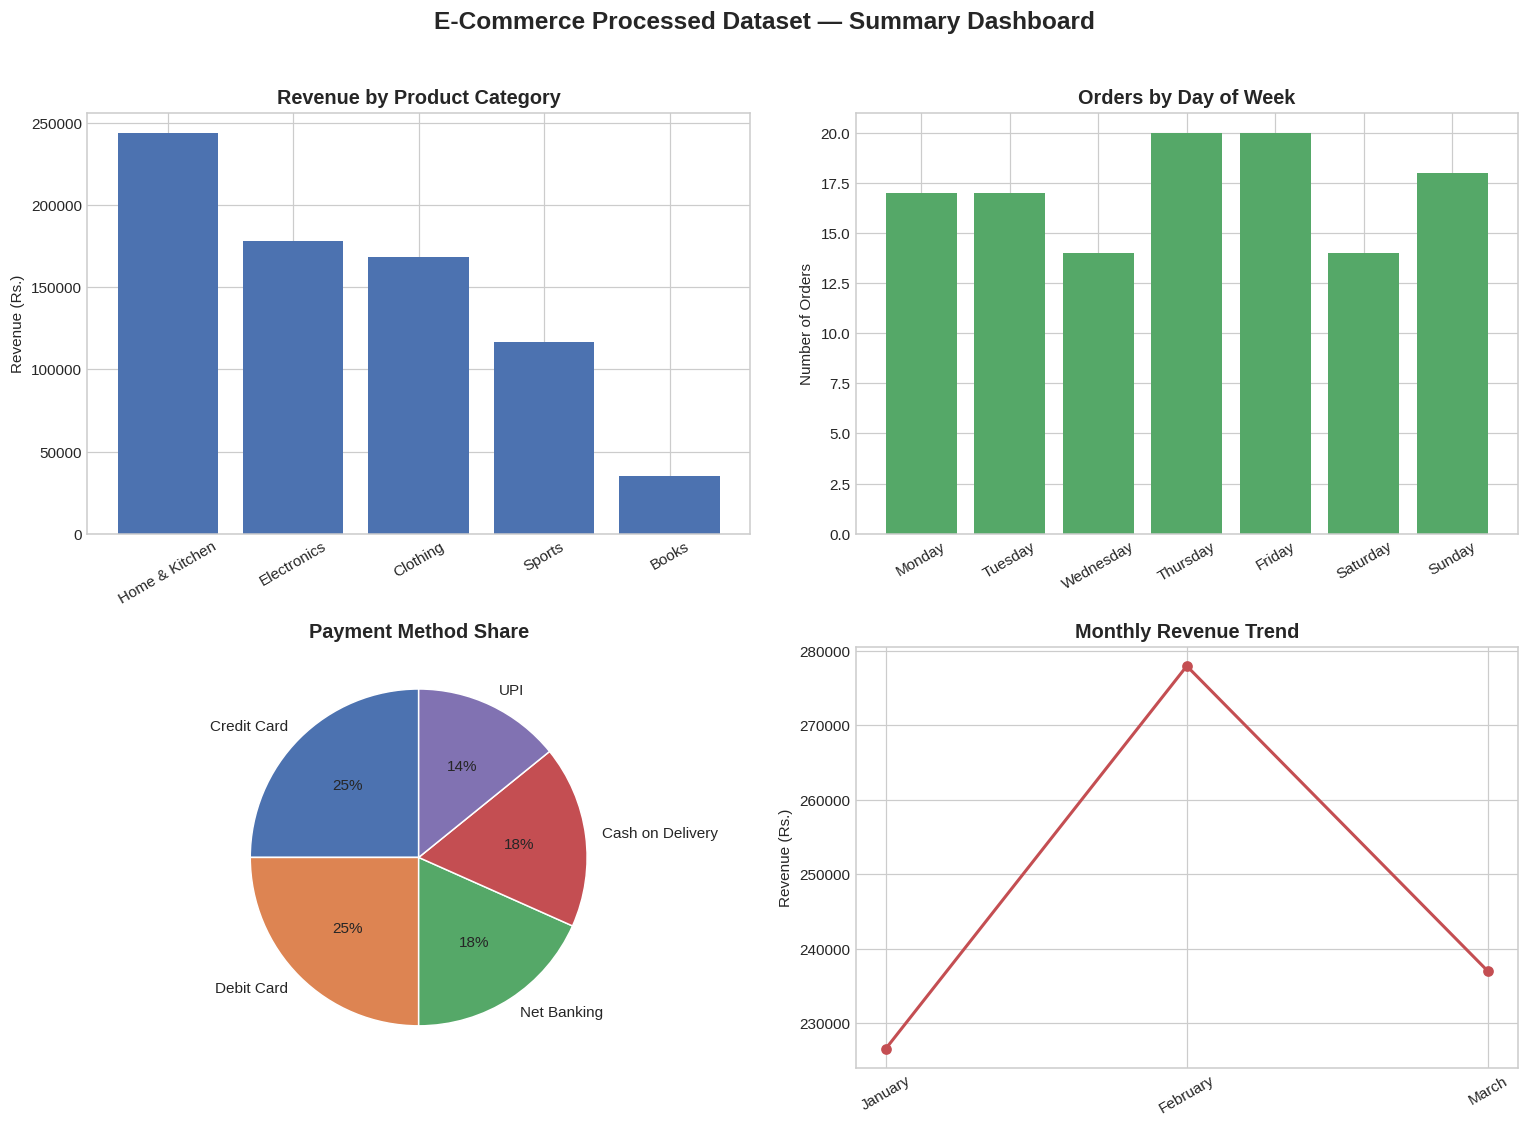

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("E-Commerce Processed Dataset — Summary Dashboard", fontsize=16, fontweight="bold", y=1.02)

# --- Panel 1: Revenue by Category ---
revenue_by_category = final_df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)
axes[0, 0].bar(revenue_by_category.index, revenue_by_category.values, color=COLOR_PALETTE[0])
axes[0, 0].set_title("Revenue by Product Category")
axes[0, 0].set_ylabel("Revenue (Rs.)")
axes[0, 0].tick_params(axis="x", rotation=30)

# --- Panel 2: Orders by Weekday ---
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
orders_by_weekday = final_df["Order_Weekday"].value_counts().reindex(weekday_order)
axes[0, 1].bar(orders_by_weekday.index, orders_by_weekday.values, color=COLOR_PALETTE[2])
axes[0, 1].set_title("Orders by Day of Week")
axes[0, 1].set_ylabel("Number of Orders")
axes[0, 1].tick_params(axis="x", rotation=30)

# --- Panel 3: Payment Method Share ---
payment_share = final_df["Payment_Method"].value_counts()
axes[1, 0].pie(payment_share.values, labels=payment_share.index, autopct="%1.0f%%",
               colors=COLOR_PALETTE, startangle=90,
               wedgeprops={"edgecolor": "white", "linewidth": 1})
axes[1, 0].set_title("Payment Method Share")

# --- Panel 4: Monthly Revenue Trend ---
monthly_revenue = final_df.groupby("Order_Month_Name")["Total_Amount"].sum()
month_sequence = ["January", "February", "March", "April", "May", "June",
                  "July", "August", "September", "October", "November", "December"]
monthly_revenue = monthly_revenue.reindex([m for m in month_sequence if m in monthly_revenue.index])
axes[1, 1].plot(monthly_revenue.index, monthly_revenue.values, marker="o",
                color=COLOR_PALETTE[3], linewidth=2)
axes[1, 1].set_title("Monthly Revenue Trend")
axes[1, 1].set_ylabel("Revenue (Rs.)")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

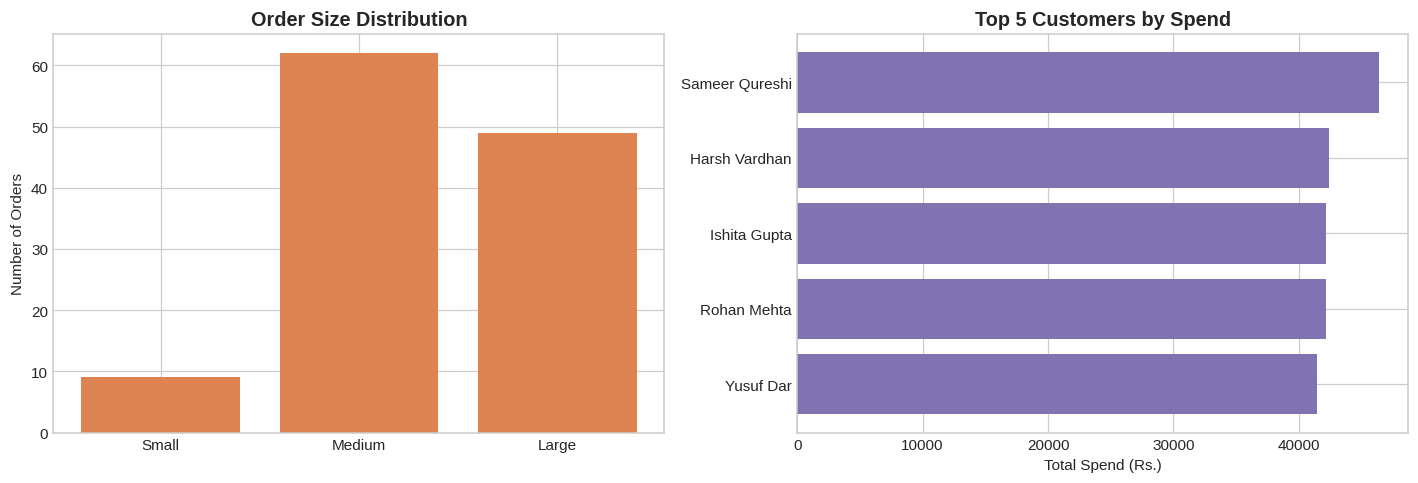

In [39]:
# Order-size distribution and top customers — quick supporting insights
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order_size_counts = final_df["Order_Size"].value_counts().reindex(["Small", "Medium", "Large"])
axes[0].bar(order_size_counts.index, order_size_counts.values, color=COLOR_PALETTE[1])
axes[0].set_title("Order Size Distribution")
axes[0].set_ylabel("Number of Orders")

top_customers = (final_df.groupby("Customer_Name")["Total_Amount"]
                  .sum().sort_values(ascending=False).head(5))
axes[1].barh(top_customers.index[::-1], top_customers.values[::-1], color=COLOR_PALETTE[4])
axes[1].set_title("Top 5 Customers by Spend")
axes[1].set_xlabel("Total Spend (Rs.)")

plt.tight_layout()
plt.show()

<a id="section11"></a>
## 1️⃣1️⃣ Exporting the Processed Dataset

The final DataFrame is exported as a CSV file — the deliverable for this
project. On Colab, it is also offered as a direct download.

In [38]:
OUTPUT_DIR = "output" if not IN_COLAB else "."
output_path = f"{OUTPUT_DIR}/Processed_Ecommerce_Dataset.csv"

final_df.to_csv(output_path, index=False)
print(f"✅ Processed dataset exported to: {output_path}")
print(f"   Final shape: {final_df.shape[0]} rows x {final_df.shape[1]} columns")

if IN_COLAB:
    from google.colab import files
    files.download(output_path)

✅ Processed dataset exported to: ./Processed_Ecommerce_Dataset.csv
   Final shape: 120 rows x 26 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<a id="section12"></a>
## ✅ 12. Conclusion

| Step | Technique | Library |
|---|---|---|
| Loaded 3 raw CSVs | `pd.read_csv()` | Pandas |
| Combined Orders + Customers + Products | `pd.merge()` | Pandas |
| Recombined Delivered / Non-Delivered subsets | `pd.concat()` | Pandas |
| Extracted year, month, weekday, weekend flag | `pd.to_datetime()`, `.dt` | Pandas |
| Computed `Total_Amount`, `Customer_Tier_Score` | `.apply()` | Pandas |
| Bucketed `Order_Size`, flagged high-value & outlier orders | `np.select`, `np.where`, `np.percentile` | NumPy |
| Statistical summaries (mean, median, std, IQR) | `np.mean`, `np.median`, `np.std` | NumPy |
| Built a 6-chart summary dashboard | subplots, bar, pie, line | Matplotlib |
| Exported the final dataset | `.to_csv()` | Pandas |

**Output file:** `output/Processed_Ecommerce_Dataset.csv`

This processed, feature-rich dataset is now ready to power downstream
analysis — sales trend reports, customer segmentation models, or BI
dashboards (Power BI / Tableau / Looker Studio).

---
<div align="center">

**Thank you for reviewing this notebook!**

</div>